In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv("../data/Cleaned_data2022-2025.csv")

In [3]:
data

,Driver,Circuit,Year,LapNumber,LapsRemaining,Compound,TyreLife,TrackStatusSimple,Position,AirTemp,...,Pressure,TrackTemp,WindDirection,WindSpeed,Stint,Rainfall,InLap,OutLap,LapTimeSeconds,TargetLapTime
0,ALB,Austin,2022,1.0,55.0,MEDIUM,1.0,2,9.0,28.9,...,991.5,34.6,92,3.9,1.0,False,0,0,109.136,105.350
1,ALB,Austin,2022,2.0,54.0,MEDIUM,2.0,1,10.0,28.9,...,991.7,34.6,112,4.3,1.0,False,0,0,105.350,104.781
2,ALB,Austin,2022,3.0,53.0,MEDIUM,3.0,1,10.0,28.9,...,991.5,34.7,105,4.5,1.0,False,0,0,104.781,105.143
3,ALB,Austin,2022,4.0,52.0,MEDIUM,4.0,1,11.0,29.0,...,991.5,34.7,106,5.8,1.0,False,0,0,105.143,106.242
4,ALB,Austin,2022,5.0,51.0,MEDIUM,5.0,1,12.0,29.0,...,991.5,34.6,103,7.0,1.0,False,0,0,106.242,104.688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89159,VER,Zandvoort,2025,67.0,5.0,SOFT,17.0,4,2.0,19.4,...,1006.0,28.0,189,1.6,3.0,False,0,0,122.527,122.461
89160,VER,Zandvoort,2025,68.0,4.0,SOFT,18.0,4,2.0,19.4,...,1006.0,28.0,179,1.3,3.0,False,0,0,122.461,73.231
89161,VER,Zandvoort,2025,69.0,3.0,SOFT,19.0,1,2.0,19.5,...,1006.0,28.0,170,1.2,3.0,False,0,0,73.231,72.921
89162,VER,Zandvoort,2025,70.0,2.0,SOFT,20.0,1,2.0,19.4,...,1006.0,27.6,208,1.5,3.0,False,0,0,72.921,73.019


In [4]:
data.columns

Index(['Driver', 'Circuit', 'Year', 'LapNumber', 'LapsRemaining', 'Compound',
       'TyreLife', 'TrackStatusSimple', 'Position', 'AirTemp', 'Humidity',
       'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'Stint',
       'Rainfall', 'InLap', 'OutLap', 'LapTimeSeconds', 'TargetLapTime'],
      dtype='object')

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [6]:
cat_features = [
    'Driver',
    'Circuit',
    'Year',
    'Compound',
    'TrackStatusSimple',
    'Rainfall',
    'Stint',
    'Position',
]

num_features = [
    'LapNumber',
    'LapsRemaining',
    'TyreLife',
    'AirTemp',
    'Humidity',
    'Pressure',
    'TrackTemp',
    'WindDirection',
    'WindSpeed',
    'LapTimeSeconds',
]

binary_features = [
    'InLap',
    'OutLap'
]

### Preprocessing (scaling, one hot encoding, etc)
no need to scale for trees

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_features),
        ("binary","passthrough",binary_features),
        ("num","passthrough",num_features),
    ]
)


### Train test Split

In [8]:
X = data.drop(columns=["TargetLapTime"])
y = data["TargetLapTime"]

In [9]:
test_races = [
    "Shanghai",
    "Silverstone",
    "Spa-Francorchamps",
    "Spielberg",
    "Suzuka",
    "São Paulo",
    "Yas Island",
    "Zandvoort"
]

In [10]:
test_mask = (
    (data["Year"] == 2025) & 
    (data["Circuit"].isin(test_races))
)

In [11]:
train_data = data[~test_mask].copy()
test_data = data[test_mask].copy()

In [12]:
X_train = train_data.drop(columns=["TargetLapTime"])
y_train = train_data["TargetLapTime"].copy()

X_test = test_data.drop(columns=["TargetLapTime"])
y_test = test_data["TargetLapTime"].copy()

In [17]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ))
])

model_xg = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=50,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

In [18]:
model_rf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Driver','Circuit','Year',...,'InLap','OutLap','LapTimeSeconds']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [19]:
model_xg.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Driver','Circuit','Year',...,'InLap','OutLap','LapTimeSeconds']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [21]:
predictions_rf = model_rf.predict(X_test)
predictions_xg = model_xg.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_rf = mean_absolute_error(y_test, predictions_rf)
rmse_rf = root_mean_squared_error(y_test, predictions_rf)

print(f"rf MAE: {mae_rf:.2f}s")
print(f"rf RMSE: {rmse_rf:.2f}s")

mae_xg = mean_absolute_error(y_test, predictions_xg)
rmse_xg = root_mean_squared_error(y_test, predictions_xg)

print(f"xg MAE: {mae_xg:.2f}s")
print(f"xg RMSE: {rmse_xg:.2f}s")

rf MAE: 3.50s
rf RMSE: 7.72s
xg MAE: 3.33s
xg RMSE: 7.32s


In [24]:
results = test_data.copy()

results["Prediction_rf"] = predictions_rf
results["Error_rf"] = results["Prediction_rf"] - results["TargetLapTime"]
results["AbsoluteError_rf"] = results["Error_rf"].abs()

results["Prediction_xg"] = predictions_xg
results["Error_xg"] = results["Prediction_xg"] - results["TargetLapTime"]
results["AbsoluteError_xg"] = results["Error_xg"].abs()

results

,Driver,Circuit,Year,LapNumber,LapsRemaining,Compound,TyreLife,TrackStatusSimple,Position,AirTemp,...,InLap,OutLap,LapTimeSeconds,TargetLapTime,Prediction_rf,Error_rf,AbsoluteError_rf,Prediction_xg,Error_xg,AbsoluteError_xg
80602,ALB,Shanghai,2025,1.0,55.0,MEDIUM,1.0,2,11.0,27.3,...,0,0,105.273,99.443,110.40848,10.96548,10.96548,103.428162,3.985162,3.985162
80603,ALB,Shanghai,2025,2.0,54.0,MEDIUM,2.0,2,11.0,27.4,...,0,0,99.443,99.095,101.77144,2.67644,2.67644,101.799309,2.704309,2.704309
80604,ALB,Shanghai,2025,3.0,53.0,MEDIUM,3.0,2,11.0,27.3,...,0,0,99.095,99.046,100.62300,1.57700,1.57700,101.286270,2.240270,2.240270
80605,ALB,Shanghai,2025,4.0,52.0,MEDIUM,4.0,1,11.0,27.4,...,0,0,99.046,98.546,99.15388,0.60788,0.60788,98.923141,0.377141,0.377141
80606,ALB,Shanghai,2025,5.0,51.0,MEDIUM,5.0,1,11.0,27.3,...,0,0,98.546,99.123,114.92092,15.79792,15.79792,98.505241,-0.617759,0.617759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89159,VER,Zandvoort,2025,67.0,5.0,SOFT,17.0,4,2.0,19.4,...,0,0,122.527,122.461,104.62250,-17.83850,17.83850,105.261742,-17.199258,17.199258
89160,VER,Zandvoort,2025,68.0,4.0,SOFT,18.0,4,2.0,19.4,...,0,0,122.461,73.231,106.42162,33.19062,33.19062,107.652664,34.421664,34.421664
89161,VER,Zandvoort,2025,69.0,3.0,SOFT,19.0,1,2.0,19.5,...,0,0,73.231,72.921,80.78158,7.86058,7.86058,75.656601,2.735601,2.735601
89162,VER,Zandvoort,2025,70.0,2.0,SOFT,20.0,1,2.0,19.4,...,0,0,72.921,73.019,73.77354,0.75454,0.75454,75.656601,2.637601,2.637601


In [40]:
# This is baseline for now, may come back and try tune hyperparameters

In [25]:
print(results["Circuit"].unique())
print(results["Year"].unique())

['Shanghai' 'Silverstone' 'Spa-Francorchamps' 'Spielberg' 'Suzuka'
 'São Paulo' 'Yas Island' 'Zandvoort']
[2025]


In [29]:
def plot_race(Year, Circuit, Driver):
    race = results[
        (results["Year"] == Year) &
        (results["Circuit"] == Circuit) & 
        (results["Driver"] == Driver)
    ]

    plt.figure(figsize=(12,6))
    
    plt.plot(
        race["LapNumber"],
        race["TargetLapTime"],
        label=f"{Driver} actual",
    )

    plt.plot(
        race["LapNumber"],
        race["Prediction_rf"],
        label=f"{Driver} Predicted Random Forrest",
    )

    plt.plot(
        race["LapNumber"],
        race["Prediction_xg"],
        label=f"{Driver} Predicted XGBoost",
    )


    plt.xlabel("Lap Number")
    plt.ylabel("Lap Time (s)")
    plt.title(f"{Driver} {Circuit} {Year} — Actual vs Predicted")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

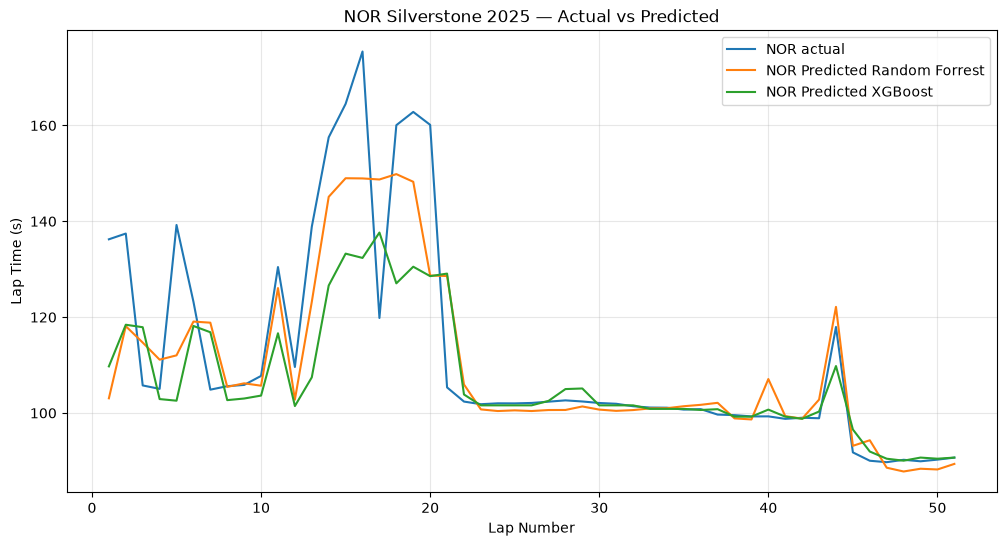

In [30]:
plot_race(2025,"Silverstone","NOR")